Esta notebook contiene bloques de código útiles para realizar Q-learning en el entorno "Continuous Mountain Car"

In [29]:
import numpy as np
import gymnasium as gym
import random 

In [30]:
# Cambiar render_mode a rgb_array para entrenar/testear sino human
env_id = 'MountainCarContinuous-v0'
env = gym.make(env_id, render_mode='rgb_array')

In [31]:
from q_learning_agent import QLearningAgent

Observation Space

In [32]:
env.observation_space

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)

Action Space

In [33]:
env.action_space

Box(-1.0, 1.0, (1,), float32)

Discretización de los estados

In [34]:
x_space = np.linspace(-1.2, 0.6, 100)
vel_space = np.linspace(-0.07, 0.07, 100)
x_space

array([-1.2       , -1.18181818, -1.16363636, -1.14545455, -1.12727273,
       -1.10909091, -1.09090909, -1.07272727, -1.05454545, -1.03636364,
       -1.01818182, -1.        , -0.98181818, -0.96363636, -0.94545455,
       -0.92727273, -0.90909091, -0.89090909, -0.87272727, -0.85454545,
       -0.83636364, -0.81818182, -0.8       , -0.78181818, -0.76363636,
       -0.74545455, -0.72727273, -0.70909091, -0.69090909, -0.67272727,
       -0.65454545, -0.63636364, -0.61818182, -0.6       , -0.58181818,
       -0.56363636, -0.54545455, -0.52727273, -0.50909091, -0.49090909,
       -0.47272727, -0.45454545, -0.43636364, -0.41818182, -0.4       ,
       -0.38181818, -0.36363636, -0.34545455, -0.32727273, -0.30909091,
       -0.29090909, -0.27272727, -0.25454545, -0.23636364, -0.21818182,
       -0.2       , -0.18181818, -0.16363636, -0.14545455, -0.12727273,
       -0.10909091, -0.09090909, -0.07272727, -0.05454545, -0.03636364,
       -0.01818182,  0.        ,  0.01818182,  0.03636364,  0.05

Obtener el estado a partir de la observación

In [35]:
def get_state(obs):
    x, vel = obs
    x_bin = np.digitize(x, x_space)
    vel_bin = np.digitize(vel, vel_space)
    return x_bin, vel_bin

In [36]:
state = get_state(np.array([-0.4, 0.02]))
state

(np.int64(45), np.int64(64))

Discretización de las acciones

In [37]:
actions = list(np.linspace(-1, 1, 10))
actions

[np.float64(-1.0),
 np.float64(-0.7777777777777778),
 np.float64(-0.5555555555555556),
 np.float64(-0.33333333333333337),
 np.float64(-0.11111111111111116),
 np.float64(0.11111111111111116),
 np.float64(0.33333333333333326),
 np.float64(0.5555555555555554),
 np.float64(0.7777777777777777),
 np.float64(1.0)]

In [38]:
def get_sample_action():
    return random.choice(actions)

Inicilización de la tabla Q

In [39]:
Q = np.zeros((len(x_space) + 1, len(vel_space) + 1, len(actions)))
Q

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

Obtención de la acción a partir de la tabla Q

In [40]:
def optimal_policy(state, Q):
    action = actions[np.argmax(Q[state])]
    return action

Epsilon-Greedy Policy

In [41]:
def epsilon_greedy_policy(state, Q, epsilon=0.1):
    explore = np.random.binomial(1, epsilon)
    if explore:
        action = get_sample_action()
    else:
        action = optimal_policy(state, Q)
        
    return action

In [43]:
# Testear el agente entrenado (sin exploración)
print("\nTesteando agente entrenado...")
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
test_rewards, test_steps = agent.test_agent(env, episodes=1, render=True)
env.close()

print(f"\nPromedio de rewards en testing: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps en testing: {np.mean(test_steps):.2f}")


Testeando agente entrenado...


KeyboardInterrupt: 

Entrenando agente Q-Learning...
Episode 800/8000 - Avg Reward: -100.82, Steps: 3000
Episode 1600/8000 - Avg Reward: -91.89, Steps: 3000
Episode 2400/8000 - Avg Reward: -83.36, Steps: 3000
Episode 3200/8000 - Avg Reward: -75.71, Steps: 3000
Episode 4000/8000 - Avg Reward: -66.41, Steps: 3000
Episode 4800/8000 - Avg Reward: -57.17, Steps: 3000
Episode 5600/8000 - Avg Reward: -49.23, Steps: 3000
Episode 6400/8000 - Avg Reward: -40.36, Steps: 3000
Episode 7200/8000 - Avg Reward: -31.24, Steps: 3000
Episode 8000/8000 - Avg Reward: -22.11, Steps: 3000


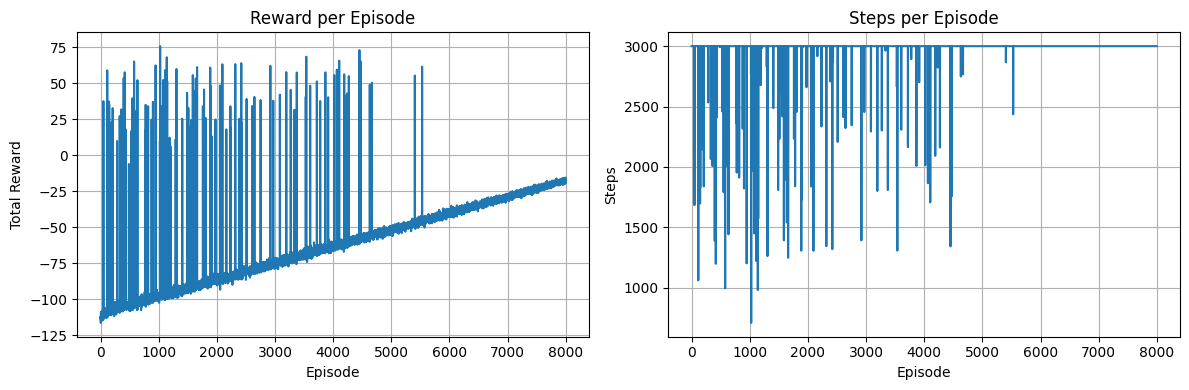

In [42]:
from q_learning_agent import QLearningAgent

# Crear agente con configuración inicial
agent = QLearningAgent(x_bins=100, vel_bins=100, action_bins=20)

# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
agent.train_agent(
    env, 
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.15,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamiento
agent.plot_training_history()

# Mostrar tasa de éxito en entrenamiento
#train_successes = sum(agent.training_history['successes'])
#print(f"\nÉxitos en entrenamiento: {train_successes}/{len(agent.training_history['successes'])} ({train_successes / len(agent.training_history['successes']) * 100:.1f}%)")

In [45]:
from dyna_q_agent import DynaQAgent

Entrenando agente Dyna-Q...
Episode 500/5000 - Avg Reward: -34.92, Steps: 1000, Success: 0.6%
Episode 1000/5000 - Avg Reward: -31.41, Steps: 655, Success: 1.0%
Episode 1500/5000 - Avg Reward: -22.84, Steps: 1000, Success: 6.8%
Episode 2000/5000 - Avg Reward: -3.76, Steps: 1000, Success: 22.8%
Episode 2500/5000 - Avg Reward: 20.28, Steps: 721, Success: 42.8%
Episode 3000/5000 - Avg Reward: 40.02, Steps: 1000, Success: 59.0%
Episode 3500/5000 - Avg Reward: 52.36, Steps: 589, Success: 69.0%
Episode 4000/5000 - Avg Reward: 67.82, Steps: 376, Success: 82.2%
Episode 4500/5000 - Avg Reward: 77.24, Steps: 234, Success: 89.4%
Episode 5000/5000 - Avg Reward: 88.10, Steps: 174, Success: 98.2%
Modelo guardado en dyna_agent_trained.npy


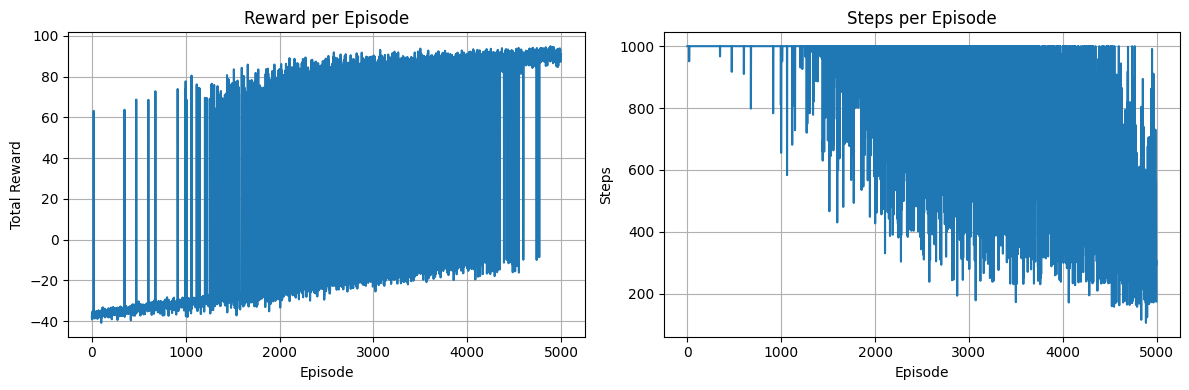

In [ ]:
# Crear agente con configuración inicial
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)

# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Dyna-Q...")
agent.train_agent(
    env, 
    episodes=5000,
    alpha=0.03,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.2,
    max_steps=1000,
    planning_steps=20
)
env.close()

# Guardar el modelo entrenado
agent.save_model('dyna_agent_trained.npy')

# Visualizar progreso de entrenamiento
agent.plot_training_history()

In [46]:
# Cargar un modelo Dyna-Q guardado y evaluarlo
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Evaluando el modelo cargado...")
test_rewards, test_steps, success_count = agent.test_agent(env, episodes=5, render=False)
env.close()

print(f"\nExitos en testing: {success_count}/5")
print(f"Promedio de rewards: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps: {np.mean(test_steps):.2f}")

Modelo cargado desde dyna_agent_trained.npy (Q shape: (101, 101, 20))
Evaluando el modelo cargado...
Test Episode 1 - Reward: 94.70, Steps: 225, Success: 1
Test Episode 2 - Reward: 94.65, Steps: 115, Success: 1
Test Episode 3 - Reward: -1.11, Steps: 4000, Success: 0
Test Episode 4 - Reward: 94.50, Steps: 333, Success: 1
Test Episode 5 - Reward: 94.80, Steps: 116, Success: 1

Exitos en testing: 4/5
Promedio de rewards: 75.51
Promedio de steps: 957.80


# Q-Learning variando el epsilon

In [47]:
from q_learning_agent import QLearningAgent

# Crear agente con configuración inicial
agent = QLearningAgent(x_bins=100, vel_bins=100, action_bins=20)

Entrenando agente Q-Learning...
Episode 800/8000 - Avg Reward: -98.55, Steps: 3000
Episode 1600/8000 - Avg Reward: -91.90, Steps: 3000
Episode 2400/8000 - Avg Reward: -81.73, Steps: 3000
Episode 3200/8000 - Avg Reward: -72.74, Steps: 3000
Episode 4000/8000 - Avg Reward: -62.89, Steps: 3000
Episode 4800/8000 - Avg Reward: -53.00, Steps: 3000
Episode 5600/8000 - Avg Reward: -43.72, Steps: 3000
Episode 6400/8000 - Avg Reward: -34.24, Steps: 3000
Episode 7200/8000 - Avg Reward: -24.29, Steps: 3000
Episode 8000/8000 - Avg Reward: -14.23, Steps: 3000


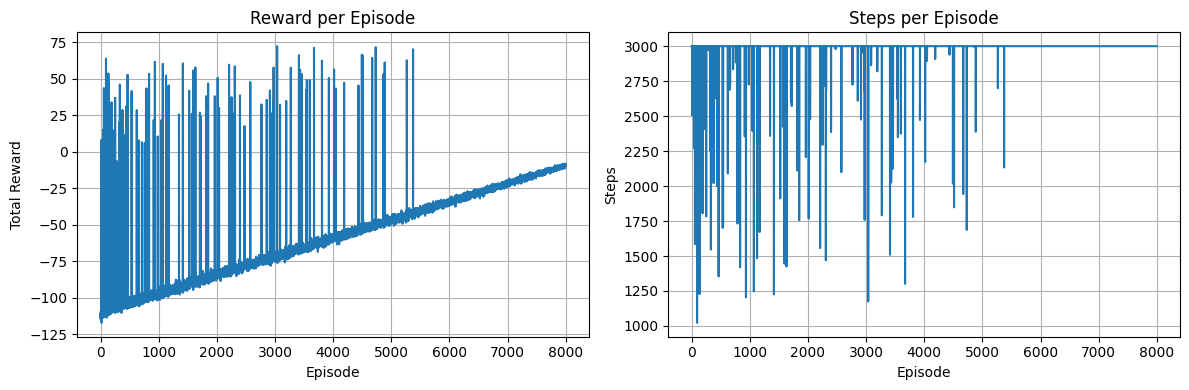

In [48]:
# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
agent.train_agent(
    env, 
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.075,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamiento
agent.plot_training_history()

Entrenando agente Q-Learning...
Episode 800/8000 - Avg Reward: -95.59, Steps: 3000
Episode 1600/8000 - Avg Reward: -88.34, Steps: 3000
Episode 2400/8000 - Avg Reward: -78.96, Steps: 3000
Episode 3200/8000 - Avg Reward: -68.30, Steps: 3000
Episode 4000/8000 - Avg Reward: -60.26, Steps: 3000
Episode 4800/8000 - Avg Reward: -50.54, Steps: 3000
Episode 5600/8000 - Avg Reward: -40.13, Steps: 3000
Episode 6400/8000 - Avg Reward: -29.86, Steps: 3000
Episode 7200/8000 - Avg Reward: -19.53, Steps: 3000
Episode 8000/8000 - Avg Reward: -9.04, Steps: 3000


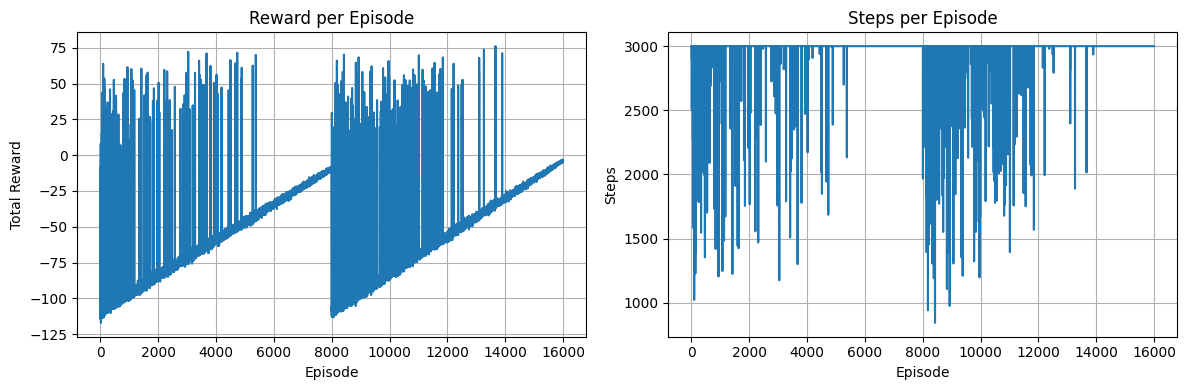

In [49]:
# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
agent.train_agent(
    env, 
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.025,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamiento
agent.plot_training_history()

Entrenando agente Q-Learning...
Episode 800/8000 - Avg Reward: -91.62, Steps: 3000
Episode 1600/8000 - Avg Reward: -85.72, Steps: 3000
Episode 2400/8000 - Avg Reward: -76.88, Steps: 3000
Episode 3200/8000 - Avg Reward: -68.09, Steps: 3000
Episode 4000/8000 - Avg Reward: -58.04, Steps: 3000
Episode 4800/8000 - Avg Reward: -48.56, Steps: 3000
Episode 5600/8000 - Avg Reward: -38.23, Steps: 3000
Episode 6400/8000 - Avg Reward: -28.04, Steps: 3000
Episode 7200/8000 - Avg Reward: -17.24, Steps: 3000
Episode 8000/8000 - Avg Reward: -6.43, Steps: 3000


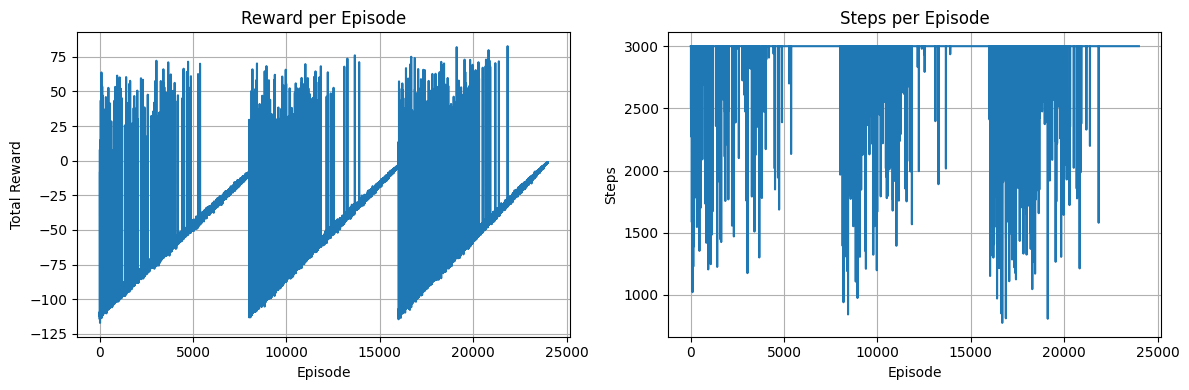

In [50]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
agent.train_agent(
    env, 
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamiento
agent.plot_training_history()

Entrenando agente Q-Learning...
Episode 550/5500 - Avg Reward: -94.52, Steps: 3000
Episode 1100/5500 - Avg Reward: -87.62, Steps: 3000
Episode 1650/5500 - Avg Reward: -73.88, Steps: 3000
Episode 2200/5500 - Avg Reward: -64.68, Steps: 3000
Episode 2750/5500 - Avg Reward: -54.39, Steps: 3000
Episode 3300/5500 - Avg Reward: -43.04, Steps: 3000
Episode 3850/5500 - Avg Reward: -27.89, Steps: 3000
Episode 4400/5500 - Avg Reward: -2.66, Steps: 3000
Episode 4950/5500 - Avg Reward: 49.82, Steps: 2147
Episode 5500/5500 - Avg Reward: 87.34, Steps: 1709


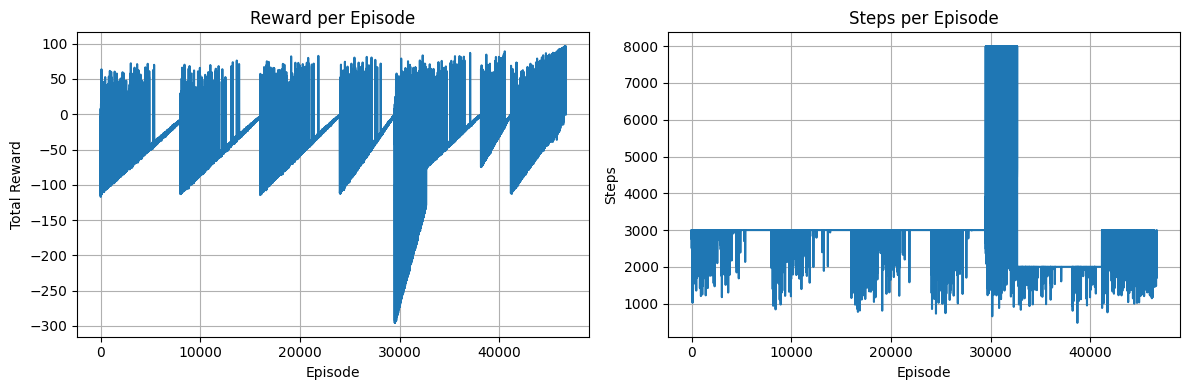

In [56]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
agent.train_agent(
    env, 
    episodes=5500,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.0005,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamiento
agent.plot_training_history()

In [61]:
# Testear el agente entrenado (sin exploración)
print("\nTesteando agente entrenado...")
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
test_rewards, test_steps = agent.test_agent(env, episodes=15, render=True)
env.close()

print(f"\nPromedio de rewards en testing: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps en testing: {np.mean(test_steps):.2f}")


Testeando agente entrenado...
Test Episode 1 - Reward: 95.39, Steps: 2035
Test Episode 2 - Reward: 96.53, Steps: 1925
Test Episode 3 - Reward: 95.31, Steps: 1945
Test Episode 4 - Reward: 95.75, Steps: 2055
Test Episode 5 - Reward: 95.21, Steps: 2023
Test Episode 6 - Reward: 95.77, Steps: 1790
Test Episode 7 - Reward: 95.88, Steps: 1879
Test Episode 8 - Reward: 96.48, Steps: 1850
Test Episode 9 - Reward: 95.25, Steps: 2087
Test Episode 10 - Reward: 95.42, Steps: 2016
Test Episode 11 - Reward: 96.79, Steps: 1694
Test Episode 12 - Reward: 95.33, Steps: 1905
Test Episode 13 - Reward: 96.56, Steps: 1778
Test Episode 14 - Reward: 95.56, Steps: 2016
Test Episode 15 - Reward: 95.97, Steps: 1874

Promedio de rewards en testing: 95.81
Promedio de steps en testing: 1924.80


Disminucion de cantidad de pasos

Entrenando agente Q-Learning...
Episode 550/5500 - Avg Reward: -67.01, Steps: 2000
Episode 1100/5500 - Avg Reward: -59.60, Steps: 2000
Episode 1650/5500 - Avg Reward: -52.36, Steps: 2000
Episode 2200/5500 - Avg Reward: -46.28, Steps: 2000
Episode 2750/5500 - Avg Reward: -38.64, Steps: 2000
Episode 3300/5500 - Avg Reward: -32.18, Steps: 2000
Episode 3850/5500 - Avg Reward: -24.38, Steps: 2000
Episode 4400/5500 - Avg Reward: -18.72, Steps: 2000
Episode 4950/5500 - Avg Reward: -11.31, Steps: 2000
Episode 5500/5500 - Avg Reward: -4.22, Steps: 2000


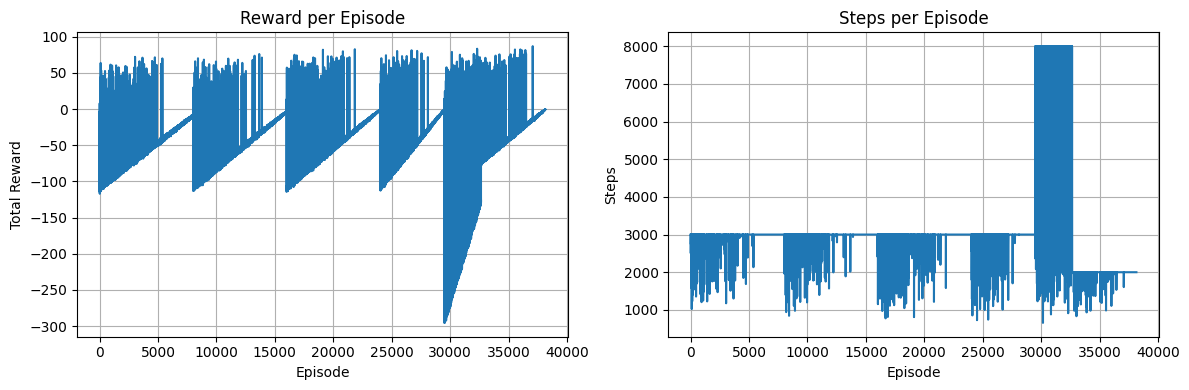

In [53]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
agent.train_agent(
    env, 
    episodes=5500,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.0005,
    max_steps=2000
)
env.close()

# Visualizar progreso de entrenamiento
agent.plot_training_history()

Entrenando agente Q-Learning...
Episode 300/3000 - Avg Reward: -65.98, Steps: 1544
Episode 600/3000 - Avg Reward: -56.88, Steps: 2000
Episode 900/3000 - Avg Reward: -51.70, Steps: 1120
Episode 1200/3000 - Avg Reward: -46.50, Steps: 2000
Episode 1500/3000 - Avg Reward: -39.22, Steps: 2000
Episode 1800/3000 - Avg Reward: -31.83, Steps: 2000
Episode 2100/3000 - Avg Reward: -24.82, Steps: 2000
Episode 2400/3000 - Avg Reward: -17.05, Steps: 2000
Episode 2700/3000 - Avg Reward: -11.45, Steps: 2000
Episode 3000/3000 - Avg Reward: -4.23, Steps: 2000


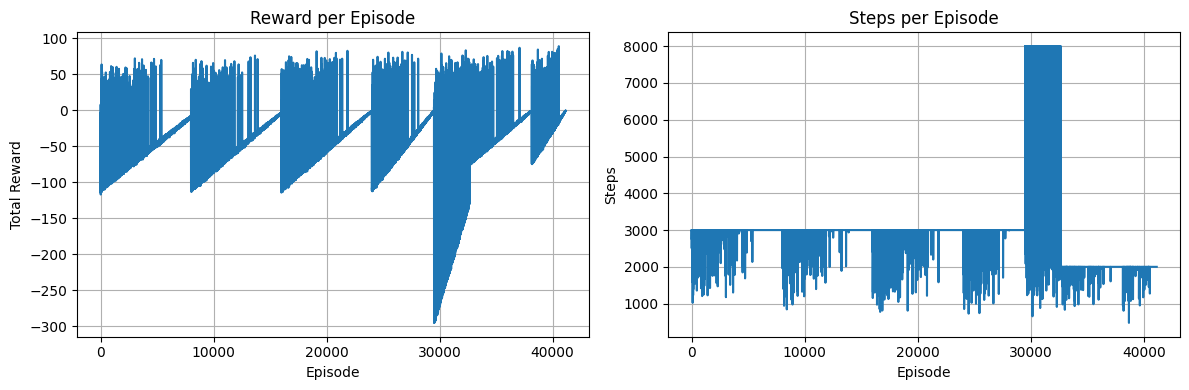

In [54]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
agent.train_agent(
    env, 
    episodes=3000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.0005,
    max_steps=2000
)
env.close()

# Visualizar progreso de entrenamiento
agent.plot_training_history()

Variando el epsilon start

In [ ]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
agent.train_agent(
    env, 
    episodes=6000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.75, 
    epsilon_end=0.025,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamiento
agent.plot_training_history()

# Epsilon Decay Exponencial